## Bland-Altman analysis to investigate intra-scanner variability of SC

In [48]:
import h5py
import numpy as np
import pandas as pd
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from scipy.spatial.distance import euclidean
from simulate_sc import (
    simulate_sc_no_bias,
    simulate_sc_noisy_copies,
    simulate_sc_length_bias,
    simulate_sc_density_bias,
    simulate_sc_fns,
    simulate_sc_fps,
)
from ba_plot import ba_plot


atlas_path = "/data/probconnatlas/wm.connatlas.scale1.h5"

### Simulate SC matrices with a set biases
We will use simulated SC matrices with an artifical set bias in the within-scanner variability to develop a Bland-Altman analysis capable of detecting such biases. 
Once the methodology is refined, we will apply it on the real HCPh data.

In [49]:
SC_matrices, noise = simulate_sc_density_bias(atlas_path=atlas_path, connectome_atlas_as_ref=False, num_sessions=16, atlas_dim=5)
#SC_matrices, noise = simulate_sc_density_bias(atlas_path=atlas_path)
num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]
#noise = np.zeros((num_sessions, atlas_dim, atlas_dim))

Simulating a reference SC matrix using a log-normal distribution.
Simulated a series of 16 SC matrices of shape (5x5) with higher variability (std=100) in lower density connections.


### Prepare the dataframe to input into the Bland-Altman analyses

We first prepare an SC matrices array by keeping only the lower triangle of each SC matrix and unravel it into a row vector.

In [50]:
# Extract the lower triangle of each SC matrix and unravel it into a row vector
SC_matrices_tril = np.array(
    [SC_matrices[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)

noise_tril = np.array(
    [noise[i][np.tril_indices(atlas_dim, k=-1)] for i in range(num_sessions)]
)
print(SC_matrices_tril.shape)
# Test whether the shape is as expected
assert SC_matrices_tril.shape == (num_sessions, atlas_dim * (atlas_dim - 1) // 2)

(16, 10)


We randomly assign half of the session to one group and the other half to another group. We will consider those two random groups as our two methods of measurements. Once the group assignement is made, we count the repetition index of each session within the group. Finally, we combine all these information in a dataframe.

In [51]:
def assign_repl(random_group):
    # DO WE NEED TO RANDOMIZE REPLICATION ASSIGNEMENT OR WE PRESERVE THE ORIGINAL SESSION ORDER (= what we do for now)?
    # Generate a vector that establishes the repetition index based on random group assignment
    count_group2 = np.cumsum(random_group == 2)
    indices1 = np.where(random_group == 1)
    count_group2[indices1] = 0

    count_group1 = np.cumsum(random_group == 1)
    indices2 = np.where(random_group == 2)
    count_group1[indices2] = 0
    repl = count_group1 + count_group2

    return repl


# Randomly assign half of the sessions to one group and half to another, we will consider those two random groups as our two methods of measurement
random_group = np.random.permutation(
    [1] * int(num_sessions / 2) + [2] * int(num_sessions / 2)
)  # DO WE NEED THIS TO BE REPRODUCIBLE OR NOT?
# Establish the repetition index
repl = assign_repl(random_group)
print(f"Random group vector: {random_group}")
print(f"Replication vector: {repl}")
# Test if the function behaves as it should
assert np.array_equal(
    assign_repl(np.array([2, 2, 1, 2, 1, 2])), [1, 2, 1, 3, 2, 4]
), f"{assign_repl([2, 2, 1, 2, 1, 2])} != [1, 2, 1, 3, 2, 4], establishement of repetition index is broken"

Random group vector: [2 1 1 2 2 2 1 1 1 1 1 2 2 2 2 1]
Replication vector: [1 1 2 2 3 4 3 4 5 6 7 5 6 7 8 8]


In [52]:
# Create a DataFrame combining random_group, repl, and SC_matrices_tril
df_sc = pd.DataFrame(
    SC_matrices_tril,
    columns=[f"connection_{i}" for i in range(SC_matrices_tril.shape[1])],
)
df_sc.insert(0, "random_group", random_group)
df_sc.insert(1, "replication", repl)

print(df_sc)

    random_group  replication  connection_0  connection_1  connection_2  \
0              2            1      1.866393      1.555219     96.093471   
1              1            1     69.369568      2.986271     74.599966   
2              1            2      0.000000     32.331863      0.000000   
3              2            2     70.780310      0.000000      0.000000   
4              2            3     14.612455      0.000000      0.000000   
5              2            4     20.710370      0.000000    117.821372   
6              1            3      0.000000     12.965132     61.383720   
7              1            4      0.000000      0.000000      0.000000   
8              1            5      0.000000     44.915774     38.379406   
9              1            6      1.459942      0.000000     71.032190   
10             1            7      0.000000     22.804380      0.000000   
11             2            5      0.000000     28.175996     25.803315   
12             2         

In [53]:
# Reformat the dataset to be able to use the LME model from Cartensen 2008
df = df_sc.melt(
    id_vars=["random_group", "replication"],
    var_name="connection_index",
    value_name="sc",
)

# Replace NaN values in the 'sc' column with zero
df["sc"].fillna(0, inplace=True)
print(df)

     random_group  replication connection_index         sc
0               2            1     connection_0   1.866393
1               1            1     connection_0  69.369568
2               1            2     connection_0   0.000000
3               2            2     connection_0  70.780310
4               2            3     connection_0  14.612455
..            ...          ...              ...        ...
155             2            5     connection_9   0.000000
156             2            6     connection_9   6.504706
157             2            7     connection_9   6.055334
158             2            8     connection_9   0.000000
159             1            8     connection_9   0.000000

[160 rows x 4 columns]


In [54]:
# import statsmodels.formula.api as smf
# md = smf.mixedlm("sc ~ random_group + connection_index", df, groups= df["connection_index"], re_formula='0 + random_group')
# mdf = md.fit()
# print(mdf.summary())


# Fit the linear mixed-effect model in R because python implementation is not able to allow different residual variance per method, which we need according to the equation in Cartensen 2008
# Convert the DataFrame to an R DataFrame
pandas2ri.activate()
r_df = pandas2ri.py2rpy(df)
r = ro.r
r.source("lme.R")
r_loa = r['estimate_loa'](r_df)
loa_df = pandas2ri.rpy2py(r_loa.rx2('loa_df'))

print(loa_df)

[1] "Start fitting model"
[1] "Model fitted after that much time: 0.0602645874023438"


TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name                 grob
1 1 (2-2,1-1) arrange      gtable[arrange]
2 2 (1-1,1-1) arrange text[GRID.text.1075]
                loa_diff      bias
random_group  116.747066 -2.009278


In [55]:
# Visualize the model fit 
r_plot = r['visualize_lmer_fit'](r_loa.rx2('fm1'))
type(r_plot)

TableGrob (2 x 1) "arrange": 2 grobs
  z     cells    name                 grob
1 1 (2-2,1-1) arrange      gtable[arrange]
2 2 (1-1,1-1) arrange text[GRID.text.1193]


rpy2.robjects.vectors.ListVector

### Compute all pair-wise session comparison

We compute all pairwise subtractions of sessions (that is rows in SC_matrices) and normalize it by the average difference of that connection.

In [56]:
# Convert NaN to zeros to correctly compute differences
SC_matrices_tril[np.isnan(SC_matrices_tril)] = 0

# Compute absolute value of pairwise subtractions for unique pairs (i, j) where i < j
sessions_subtractions = []
sessions_means = []
session_pairs = []
noise_subs = []
noise_means = []

# Choose whether to compute differences in absolute value sor not
absolute_diff = True
if absolute_diff:
    num_sub = num_sessions * (num_sessions - 1) // 2
else:
    num_sub = num_sessions * num_sessions

j_range = range(num_sessions)
for i in range(num_sessions):
    j_range = range(i + 1, num_sessions) if absolute_diff else range(num_sessions)
    for j in j_range:
        subtraction = SC_matrices_tril[i] - SC_matrices_tril[j]
        noise_sub = noise_tril[i] - noise_tril[j]
        if absolute_diff:
            subtraction = np.abs(subtraction)
            noise_sub = np.abs(noise_sub)

        means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
        n_means = np.mean(np.vstack((noise_tril[i], noise_tril[j])), axis=0)

        sessions_means.append(means)
        sessions_subtractions.append(subtraction)
        noise_means.append(n_means)
        noise_subs.append(noise_sub)
        session_pairs.append((i, j))

sessions_subtractions = np.array(sessions_subtractions)
sessions_means = np.array(sessions_means)
noise_subs = np.array(noise_subs)
noise_means = np.array(noise_means)
assert sessions_subtractions.shape == (
    num_sub,
    atlas_dim * (atlas_dim - 1) // 2,
)
assert sessions_means.shape == sessions_subtractions.shape

""" # Normalize the subtractions by the grand mean value of each connection
grand_mean = np.mean(sessions_subtractions, axis=0)
# Divide by connection grand mean only if it is not zero
non_zero_indices = np.where(grand_mean != 0)[0]
assert grand_mean.shape == (atlas_dim * (atlas_dim - 1) // 2,)
sessions_subtractions[:, non_zero_indices] = (
    sessions_subtractions[:, non_zero_indices] / grand_mean[non_zero_indices]
)
assert sessions_subtractions.shape == (
    num_sub,
    atlas_dim * (atlas_dim - 1) // 2,
) """

' # Normalize the subtractions by the grand mean value of each connection\ngrand_mean = np.mean(sessions_subtractions, axis=0)\n# Divide by connection grand mean only if it is not zero\nnon_zero_indices = np.where(grand_mean != 0)[0]\nassert grand_mean.shape == (atlas_dim * (atlas_dim - 1) // 2,)\nsessions_subtractions[:, non_zero_indices] = (\n    sessions_subtractions[:, non_zero_indices] / grand_mean[non_zero_indices]\n)\nassert sessions_subtractions.shape == (\n    num_sub,\n    atlas_dim * (atlas_dim - 1) // 2,\n) '

We will also try to compute the euclidean distance between pairs of SC matrices

In [57]:
# Compute absolute value of pairwise subtractions for unique pairs (i, j) where i < j
sessions_dist = []

j_range = range(num_sessions)
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        distance = euclidean(SC_matrices_tril[i], SC_matrices_tril[j])
        sessions_dist.append(distance)

sessions_dist = np.array(sessions_dist)
assert sessions_dist.shape == (num_sub,)

## Pre-registered analysis

Plot the BA plot for the ten connections with the largest pairwise differences (normalized by the average difference in the pool).


#### Identify the connections corresponding to the 10 largest differences

In [58]:
# Identify the 10 maximum element-wise subtractions in sessions_subtractions
max_indices = np.unravel_index(
    np.argsort(np.abs(sessions_subtractions), axis=None)[-10:],
    sessions_subtractions.shape,
)
max_values = sessions_subtractions[max_indices]
# Verify that we indeed extract the 10 maximum differences
""" assert abs(np.min(max_values)) > np.abs(
    np.max(
        np.ma.masked_array(
            sessions_subtractions, mask=np.isin(sessions_subtractions, max_values)
        )
    )
) """

print(
    f"The 10 biggest differences in a structural connection value between two sessions are: {max_values}"
)
# Extract the session pairs corresponding to the 10 biggest differences
max_session_pairs = [session_pairs[idx] for idx in max_indices[0]]

print(
    f"The session pairs corresponding to the 10 biggest differences are: {max_session_pairs}"
)
print(
    f"The connection corresponding to the 10 biggest differences are {max_indices[1]}"
)  # TO DO: match connections indices to the brain regions

The 10 biggest differences in a structural connection value between two sessions are: [257.9213607 257.9213607 257.9213607 257.9213607 257.9213607 257.9213607
 257.9213607 257.9213607 257.9213607 257.9213607]
The session pairs corresponding to the 10 biggest differences are: [(1, 5), (5, 15), (0, 5), (5, 6), (3, 5), (4, 5), (5, 13), (5, 9), (5, 12), (5, 7)]
The connection corresponding to the 10 biggest differences are [6 6 6 6 6 6 6 6 6 6]


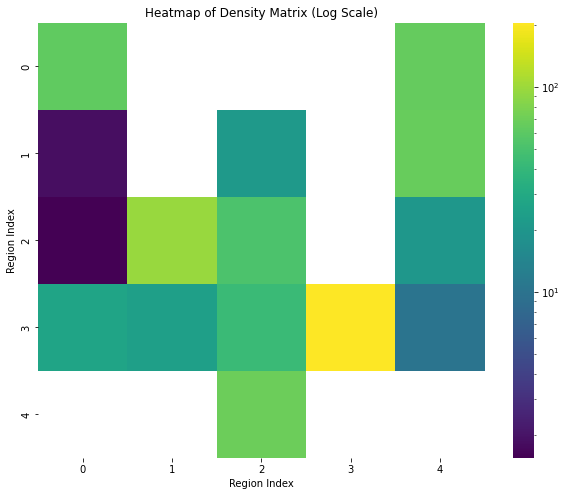

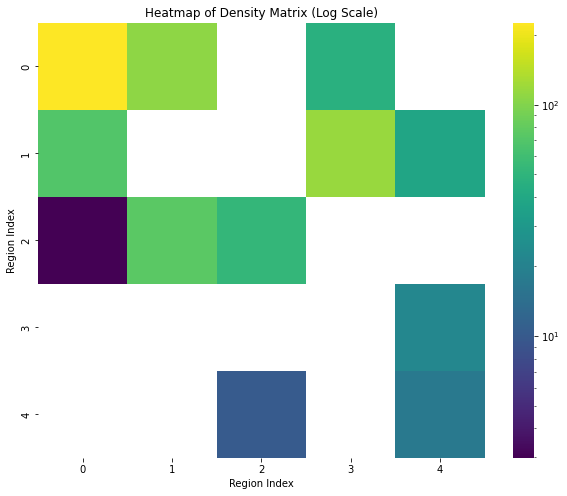

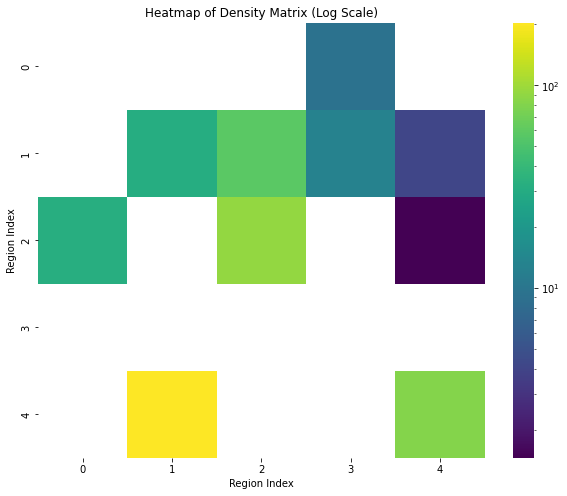

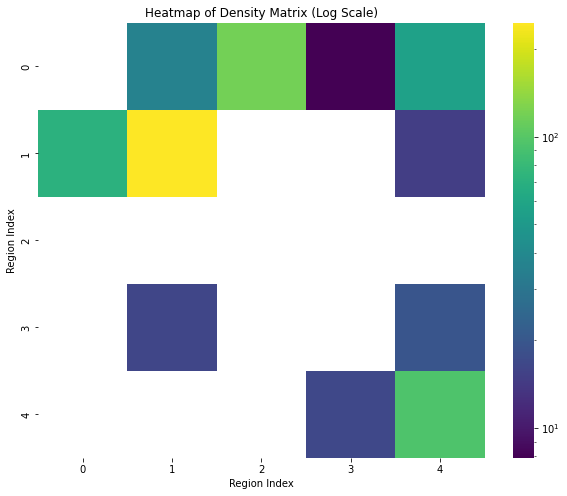

In [59]:
import seaborn as sns
from matplotlib.colors import LogNorm
from matplotlib import pyplot as plt

for i in range(4):
    density_matrix = SC_matrices[i,:,:]
    plt.figure(figsize=(10, 8))
    sns.heatmap(density_matrix, cmap='viridis', cbar=True, norm=LogNorm(vmin=np.nanmin(density_matrix[density_matrix > 0]), vmax=np.nanmax(density_matrix)))
    #sns.heatmap(density_matrix, cmap='viridis', cbar=True)
    plt.title('Heatmap of Density Matrix (Log Scale)')
    plt.xlabel('Region Index')
    plt.ylabel('Region Index')
    plt.show()

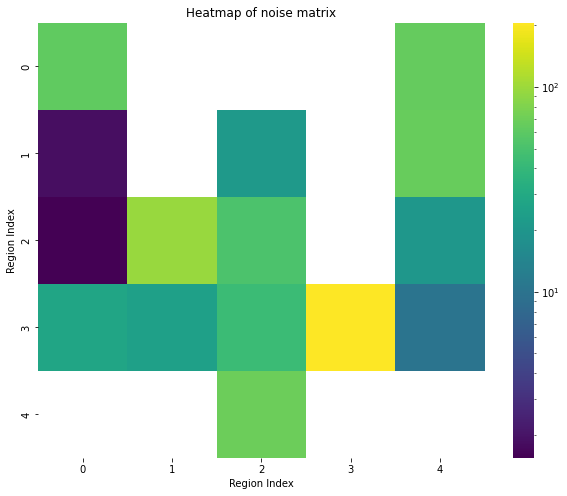

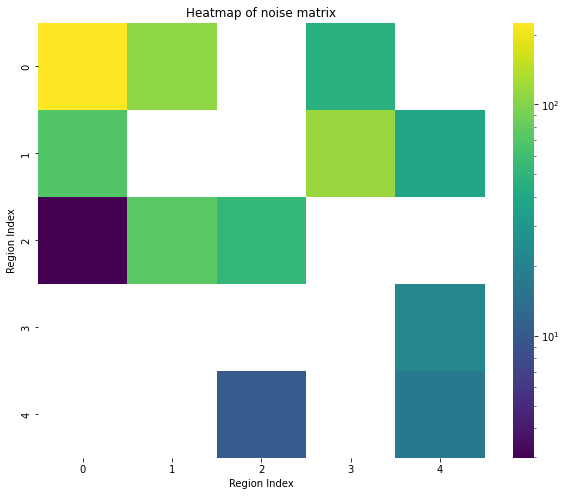

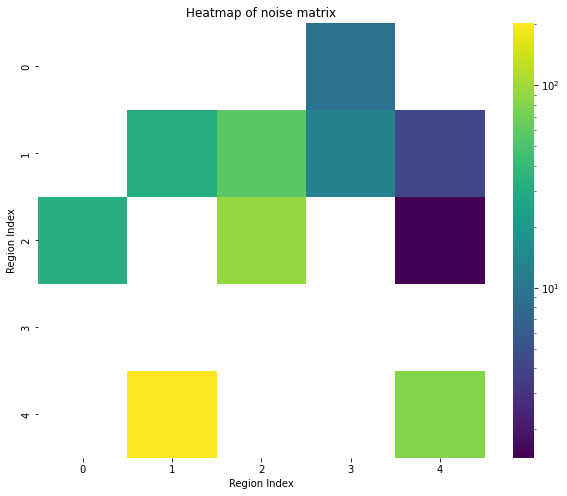

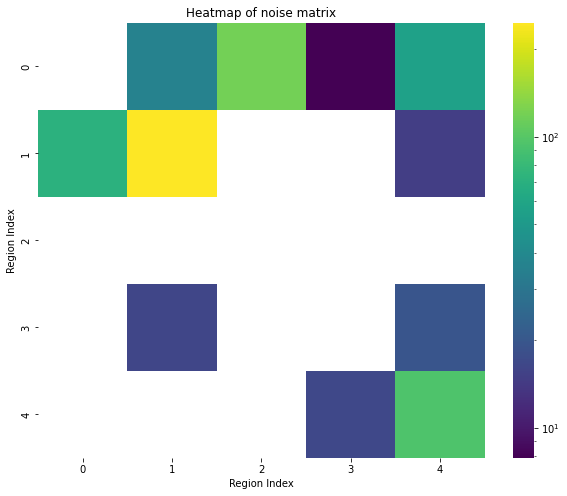

In [60]:
noise.shape
for i in range(4):
    matrix = noise[i,:,:]
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix, cmap='viridis', cbar=True, norm=LogNorm(vmin=np.nanmin(matrix[matrix > 0]), vmax=np.nanmax(matrix)))
    plt.title('Heatmap of noise matrix')
    plt.xlabel('Region Index')
    plt.ylabel('Region Index')
    plt.show()

In [61]:
# Check that all matrices elements are float
print(all(isinstance(element, np.float64) for element in SC_matrices.flatten()))
print(all(isinstance(element, np.float64) for element in noise.flatten()))

True
True


#### Plot the BA plot of the connections with the biggest differences

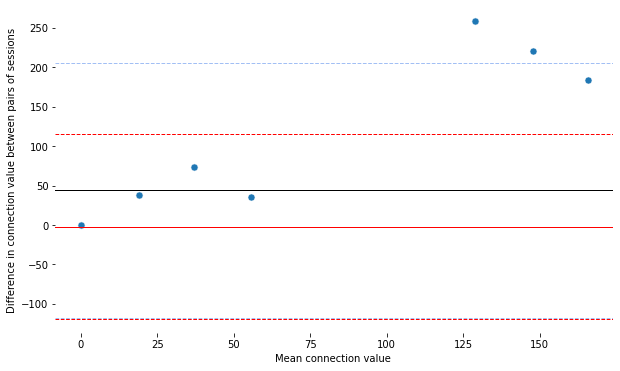

In [62]:
for conn in np.unique(max_indices[1]):
    # Extract the vector of differences and means
    conn_diff = sessions_subtractions[:, conn]
    conn_mean = sessions_means[:, conn]
    assert conn_mean.shape == (num_sub,)
    assert (
        conn_diff.shape == conn_mean.shape
    ), f"The mean vector has a shape of {conn_mean.shape} while the difference vector has a shape of {conn_diff.shape}."

    # Plot the corresponding BA plot
    ba_plot(
        diff=conn_diff,
        mean=conn_mean,
        rep_loa_estimates_df=loa_df,
    )

6


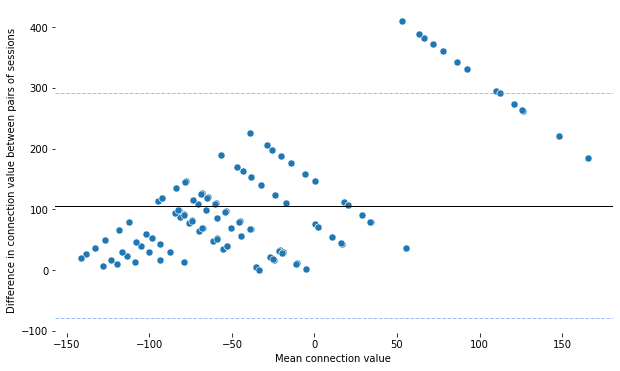

In [63]:
for conn in np.unique(max_indices[1]):
    print(conn)
    # Extract the vector of differences and means
    noise_diff = noise_subs[:, conn]
    noise_mean = noise_means[:, conn]
    assert conn_mean.shape == (num_sub,)
    assert (
        noise_diff.shape == noise_mean.shape
    ), f"The mean vector has a shape of {noise_mean.shape} while the difference vector has a shape of {noise_diff.shape}."

    # Plot the corresponding BA plot
    ba_plot(
        diff=noise_diff,
        mean=noise_mean,
    )

## Multivariate BA plot

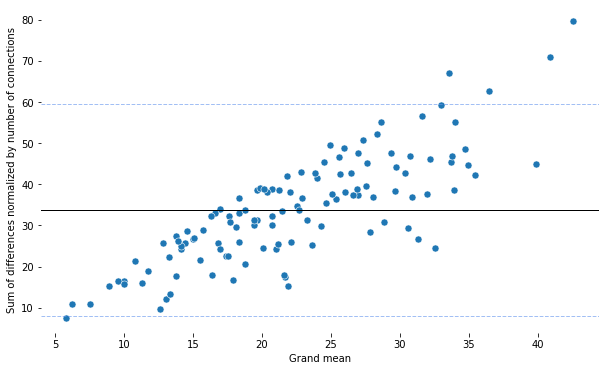

In [64]:
sum_diff = np.sum(sessions_subtractions, axis=1)
sum_diff /= SC_matrices_tril.shape[1]
# Grand mean of SC values in pairs of SC matrices
grand_mean = np.mean(sessions_means, axis=1)
assert sum_diff.shape == (num_sub,)
assert grand_mean.shape == (num_sub,)

ba_plot(diff=sum_diff, mean=grand_mean, xlabel= "Grand mean", ylabel="Sum of differences normalized by number of connections")

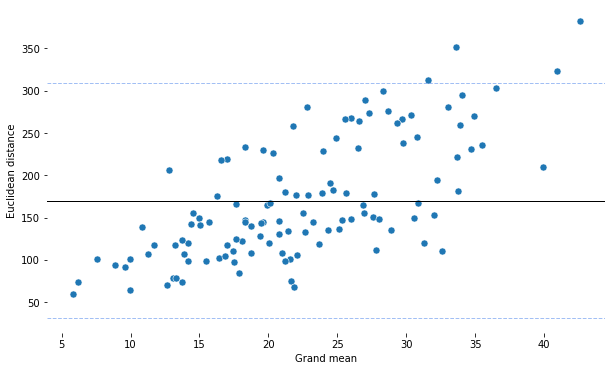

In [65]:
ba_plot(
    diff=sessions_dist,
    mean=grand_mean,
    xlabel="Grand mean",
    ylabel="Euclidean distance",
)

## BA plot with all connections, all pair-wise session comparisons

In [66]:
with h5py.File(atlas_path, "r") as f:
    length_matrix = np.array(f["matrices"]["length"])

length_tril = length_matrix[np.tril_indices(atlas_dim, k=-1)]


print(length_tril.shape)

(10,)


In [67]:
# Compute all pairwise mean for unique pairs (i, j) where i < j
sessions_means = []
for i in range(num_sessions):
    for j in range(i + 1, num_sessions):
        means = np.mean(np.vstack((SC_matrices_tril[i], SC_matrices_tril[j])), axis=0)
        sessions_means.append(means)

sessions_means = np.array(sessions_means)
sessions_means.shape

(120, 10)

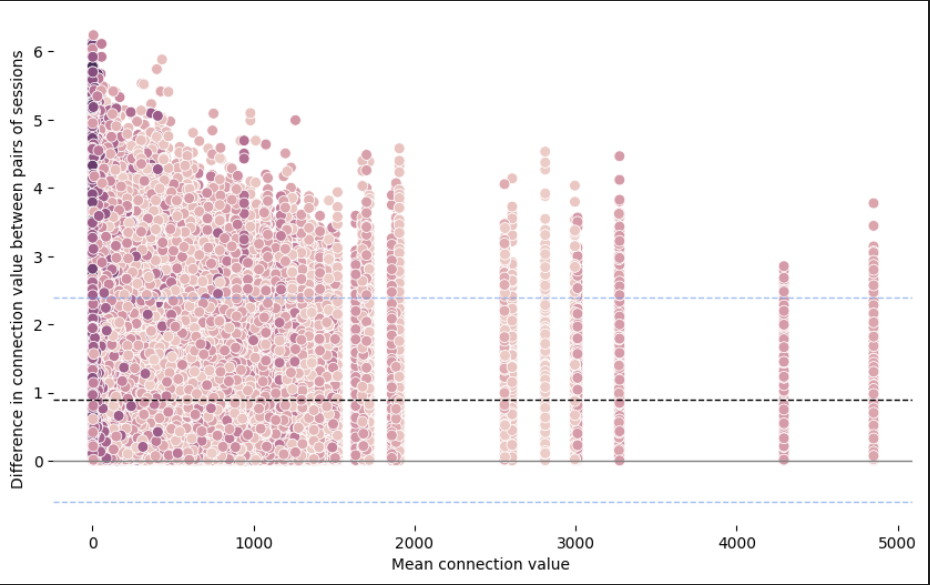

In [68]:
from IPython.display import Image, display

# length_hue = np.tile(length_tril, num_sessions * (num_sessions - 1) // 2)
# np.testing.assert_array_equal(length_hue[:len(length_tril)], length_tril)

# ba_plot(
#     diff = sessions_subtractions.flatten(),
#     mean = sessions_means.flatten(),
#     hue = length_hue,
# )
# Display the photo
image_path = (
    "/home/cprovins/Documents/HCPh_analysis/BAplot_allconnections_lengthhue.png"
)
display(Image(filename=image_path))